## Домашнє завдання 6

In [32]:
import os
import librosa
import zipfile
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
from scipy.fft import fft
from sklearn.cluster import SpectralClustering
from sklearn import metrics
from tqdm import tqdm

In [33]:
# Завантаження та розархівування датасету
url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
zip_file_path = "ESC-50-master.zip"
download_path = "./ESC-50-master/"
if not os.path.exists(download_path):
    print("Завантаження датасету...")
    urlretrieve(url, zip_file_path)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(download_path)
    os.remove(zip_file_path)
    print("Датасет завантажено та розархівовано.")
else:
    print("Датасет вже існує.")

Датасет вже існує.


In [34]:
# Read CSV file ... meta/esc50.csv
df_file_path = os.path.join(download_path, "ESC-50-master/meta", "esc50.csv")
df = pd.read_csv(df_file_path)
df.head(5)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


### 1. Завантаження даних

In [35]:
target_categories = ['dog', 'chirping_birds']
filtered_df = df[df['category'].isin(target_categories)].copy()

print(f"Загальна кількість зразків: {len(df)}")
print(f"Кількість відфільтрованих зразків: {len(filtered_df)}")
print(filtered_df['category'].value_counts())

Загальна кількість зразків: 2000
Кількість відфільтрованих зразків: 80
category
dog               40
chirping_birds    40
Name: count, dtype: int64


### 2. Генерування спектрограми, пуліенг та перетворення у вектори

In [36]:
def spectrogram(samples, sample_rate, stride_ms = 10.0, window_ms = 20.0, max_freq = None, eps = 1e-14):

    stride_size = int(0.001 * sample_rate * stride_ms)
    window_size = int(0.001 * sample_rate * window_ms)

    # Extract strided windows
    truncate_size = (len(samples) - window_size) % stride_size
    samples = samples[:len(samples) - truncate_size]
    nshape = (window_size, (len(samples) - window_size) // stride_size + 1)
    nstrides = (samples.strides[0], samples.strides[0] * stride_size)
    windows = np.lib.stride_tricks.as_strided(samples, shape = nshape, strides = nstrides)

    assert np.all(windows[:, 1] == samples[stride_size:(stride_size + window_size)])

    # Window weighting, squared Fast Fourier Transform (fft), scaling
    weighting = np.hanning(window_size)[:, None]

    fft = np.fft.rfft(windows * weighting, axis=0)
    fft = np.absolute(fft)
    fft = fft**2

    scale = np.sum(weighting**2) * sample_rate
    fft[1:-1, :] *= (2.0 / scale)
    fft[(0, -1), :] /= scale

    # Prepare fft frequency list
    freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

    # Compute spectrogram feature
    # ind = np.where(freqs <= max_freq)[0][-1] + 1
    specgram = np.log(fft[:, :] + eps)
    return specgram

def pooling_audio(mat,ksize,method='max',pad=False):
    '''Non-overlapping pooling on 2D or 3D data.

    <mat>: ndarray, input array to pool.
    <ksize>: tuple of 2, kernel size in (ky, kx).
    <method>: str, 'max for max-pooling,
                    'mean' for mean-pooling.
    <pad>: bool, pad <mat> or not. If no pad, output has size
            n//f, n being <mat> size, f being kernel size.
            if pad, output has size ceil(n/f).

    Return <result>: pooled matrix.
    '''

    m, n = mat.shape[:2]
    ky,kx=ksize

    _ceil=lambda x,y: int(np.ceil(x/float(y)))

    if pad:
        ny=_ceil(m,ky)
        nx=_ceil(n,kx)
        size=(ny*ky, nx*kx)+mat.shape[2:]
        mat_pad=np.full(size,np.nan)
        mat_pad[:m,:n,...]=mat
    else:
        ny=m//ky
        nx=n//kx
        mat_pad=mat[:ny*ky, :nx*kx, ...]

    new_shape=(ny,ky,nx,kx)+mat.shape[2:]

    if method=='max':
        result=np.nanmax(mat_pad.reshape(new_shape),axis=(1,3))
    else:
        result=np.nanmean(mat_pad.reshape(new_shape),axis=(1,3))

    return result

In [37]:
from tqdm import tqdm

feature_list = []
true_labels = []
audio_base_path = os.path.join(download_path, "ESC-50-master/audio")

target_sr = 44100 
pooling_ksize = (20, 20)

for index, row in tqdm(filtered_df.iterrows(), total=len(filtered_df), desc="Обробка файлів"):
    audio_file_path = os.path.join(audio_base_path, row['filename'])
    y, sr = librosa.load(audio_file_path, sr=target_sr)
    spect_matrix = spectrogram(y, sr)
    pooled_matrix = pooling_audio(spect_matrix, ksize=pooling_ksize, method='max')
    feature_vector = pooled_matrix.flatten()
    feature_list.append(feature_vector)
    true_labels.append(row['category'])

X = np.array(feature_list)

print(f"\nФорма матриці ознак: {X.shape}")
print(f"Кількість міток: {len(true_labels)}")

Обробка файлів: 100%|██████████| 80/80 [00:01<00:00, 65.66it/s]


Форма матриці ознак: (80, 528)
Кількість міток: 80


### 3. Кластеризація

In [38]:
# Ми знаємо, що у нас 2 класи, тому n_clusters=2
sc = SpectralClustering(n_clusters=2, 
                        random_state=42, 
                        affinity='nearest_neighbors')
clusters = sc.fit_predict(X)

results_df = pd.DataFrame({
    'True_Label': true_labels,
    'Cluster': clusters
})

print(results_df.head(20))

        True_Label  Cluster
0              dog        1
1   chirping_birds        0
2              dog        1
3              dog        1
4              dog        1
5              dog        0
6   chirping_birds        0
7   chirping_birds        0
8   chirping_birds        0
9   chirping_birds        0
10  chirping_birds        0
11  chirping_birds        0
12  chirping_birds        1
13             dog        1
14             dog        1
15             dog        1
16  chirping_birds        0
17  chirping_birds        0
18  chirping_birds        0
19             dog        1


### 4. Перевірка результатів


Матриця плутанини:
[[30 10]
 [10 30]]
(Рядки відповідають: 0='chirping_birds', 1='dog')

Adjusted Rand Index (ARI): 0.2404
Homogeneity: 0.1887
Completeness: 0.1887
V-Measure: 0.1887


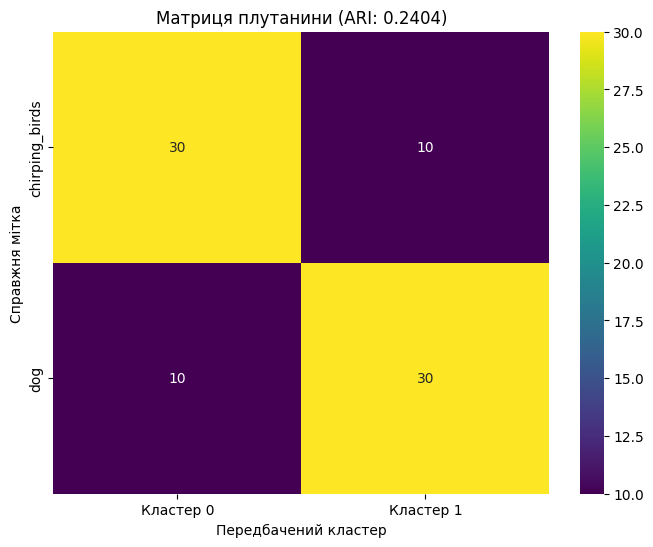

In [39]:
import seaborn as sns

label_map = {'chirping_birds': 0, 'dog': 1}

true_labels_numeric = [label_map[label] for label in true_labels]
conf_matrix = metrics.confusion_matrix(true_labels_numeric, clusters)
labels_sorted = sorted(list(label_map.keys()))

print("\nМатриця плутанини:")
print(conf_matrix)
print(f"(Рядки відповідають: 0='{labels_sorted[0]}', 1='{labels_sorted[1]}')")

ari = metrics.adjusted_rand_score(true_labels_numeric, clusters)
homogeneity = metrics.homogeneity_score(true_labels_numeric, clusters)
completeness = metrics.completeness_score(true_labels_numeric, clusters)
v_measure = metrics.v_measure_score(true_labels_numeric, clusters)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Homogeneity: {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")
print(f"V-Measure: {v_measure:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True,
    fmt='d',
    cmap='viridis', 
    xticklabels=['Кластер 0', 'Кластер 1'], 
    yticklabels=labels_sorted # ['chirping_birds', 'dog']
)
plt.title(f"Матриця плутанини (ARI: {ari:.4f})")
plt.xlabel('Передбачений кластер')
plt.ylabel('Справжня мітка')
plt.show()

### 5. Висновки

Аналіз результатів показує, що кластеризація пройшла лише частково успішно. Це підтверджується низькими метриками, наприклад ARI = 0.2404: Цей показник значно вищий за 0, але далекий від 1.0. Це вказує на слабку, але позитивну кореляцію між кластерами та справжніми мітками.

Кластер 0: Містить 30 зразків «chirping_birds» (правильно), але також 10 зразків «dog» (неправильно).

Кластер 1: Містить 30 зразків «dog» (правильно), але також 10 зразків «chirping_birds» (неправильно).

Аналогічно поза основним завданням експеримент з іншими пулінгами (10, 10), (20, 20), (30, 30)) не показав набагато кращих результатів. Найкращим виявився пулінг 30*30 з результатами

chirping_birds  30  10
dog              6  34

В цілому, звуки різного походження здебільшого потрапили в різні кластери, але зі значним перекриттям.

Перетворення Фур'є (спектрограма) є ефективним інструментом для вилучення частотних характеристик зі звуку. Можливо, для більш високого результату, потрібно інтегрувати його з трохи іншими подальшими кроками обробки замість flatten() та простої кластерізації.